In [ ]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt

class ParcelDeliveryEnv(gym.Env):
    def __init__(self):
        super(ParcelDeliveryEnv, self).__init__()
        self.grid_rows = 5
        self.grid_cols = 5
        self.action_space = spaces.Discrete(4)
        self.observation_space = spaces.Discrete(self.grid_rows * self.grid_cols)
        self.start_pos = np.array([0, 0])
        self.drone_pos = self.start_pos.copy()
        self.parcel_location = np.array([2, 2])
        self.delivery_house = np.array([0, 3])
        self.wind_zones = [np.array([4, 1]), np.array([2, 4])]
        self.no_fly_zone = np.array([4, 3])
        self.low_battery_zone = np.array([3, 1])
        self.has_parcel = False

    def reset(self, seed=None, options=None):
        self.drone_pos = self.start_pos.copy()
        self.has_parcel = False
        state = self._pos_to_state(self.drone_pos)
        return state, {}

    def step(self, action):
        if action == 0:
            self.drone_pos[1] += 1
        elif action == 1:
            self.drone_pos[1] -= 1
        elif action == 2:
            self.drone_pos[0] -= 1
        elif action == 3:
            self.drone_pos[0] += 1

        self.drone_pos[0] = np.clip(self.drone_pos[0], 0, self.grid_cols - 1)
        self.drone_pos[1] = np.clip(self.drone_pos[1], 0, self.grid_rows - 1)
        reward = -1
        terminated = False

        if np.array_equal(self.drone_pos, self.parcel_location) and not self.has_parcel:
            self.has_parcel = True
            reward += 10

        if any(np.array_equal(self.drone_pos, w) for w in self.wind_zones):
            reward -= 10

        if np.array_equal(self.drone_pos, self.low_battery_zone):
            reward -= 5

        if np.array_equal(self.drone_pos, self.no_fly_zone):
            reward -= 15

        if np.array_equal(self.drone_pos, self.delivery_house) and self.has_parcel:
            reward += 25
            terminated = True

        new_state = self._pos_to_state(self.drone_pos)
        return new_state, reward, terminated, False, {}

    def render(self):
        grid = np.zeros((self.grid_rows, self.grid_cols), dtype=object)
        for r in range(self.grid_rows):
            for c in range(self.grid_cols):
                grid[r, c] = " . "

        grid[self.parcel_location[1], self.parcel_location[0]] = " PK "
        grid[self.delivery_house[1], self.delivery_house[0]] = " DH "

        for wz in self.wind_zones:
            grid[wz[1], wz[0]] = " WZ "

        grid[self.no_fly_zone[1], self.no_fly_zone[0]] = " NF "
        grid[self.low_battery_zone[1], self.low_battery_zone[0]] = " LB "
        grid[self.drone_pos[1], self.drone_pos[0]] = " DR "

        plt.figure(figsize=(6, 6))
        plt.imshow(np.zeros((self.grid_rows, self.grid_cols)), cmap="gray_r")
        plt.grid(True)
        plt.xticks(range(self.grid_cols))
        plt.yticks(range(self.grid_rows))

        for r in range(self.grid_rows):
            for c in range(self.grid_cols):
                plt.text(c, r, grid[r, c], ha="center", va="center", fontsize=15)

        plt.title("Parcel Delivery Drone Grid World")
        plt.show()

    def _pos_to_state(self, pos):
        return pos[1] * self.grid_cols + pos[0]


In [ ]:
def chooseaction(qtable, state, eps):
 if np.random.rand() < eps:
  return np.random.randint(0, 4)
 return np.argmax(qtable[state])

def runsarsa(env, episodes, stepmax, learnrate, discountrate,
 eps, epsdrop, epsmin):
 numstates = env.observation_space.n
 numacts = env.action_space.n
 qtable = np.zeros((numstates, numacts))
 allrewards = []
 alleps = []
 for ep in range(episodes):
  state, info = env.reset()
  act = chooseaction(qtable, state, eps)
  totalreward = 0
  for step in range(stepmax):
   nextstate, reward, done, trunc, info = env.step(act)
   nextact = chooseaction(qtable, nextstate, eps)
   nowvalue = qtable[state, act]
   nextvalue = qtable[nextstate, nextact]
   newvalue = nowvalue + learnrate * (reward + discountrate *
   nextvalue - nowvalue)
   qtable[state, act] = newvalue
   totalreward += reward
   state = nextstate
   act = nextact
   if done:
    break
  eps = max(epsmin, eps * epsdrop)
  allrewards.append(totalreward)
  alleps.append(eps)
 return qtable, allrewards, alleps


Part III: Implement N-step Double Q-learning
[40 pts]
Apply the n-step Double Q-learning algorithm to solve the environment defined in Part I.
This will involve both theoretical understanding and practical implementation.
STEPS:
1. [Theoretical Task] Derive the n-step Double Q-Learning update rule:
• Mathematically derive the update rule for the n-step Double Q-learning
algorithm. Include the details in your report.
• Consider n values ranging from 1 to 5 and provide a generalizable update
rule.
Refer to Sutton & Barto’s Reinforcement Learning book, Chapters 6.1 and 7
for details.

#Derivation

In order to derive the N-step double q-learning update rule, We combine the definitions of N-step returns and double Q-learning target.

We consider the sum of discounted rewards over n-steps along with the estimated value of the state n steps in future.

for double q-learning we maintain two Q-tables, Q1 and Q2 to decouple actions.

Step1: The N-stepreturn target in standard n-step learning, the target return is the sum of the first n discounted rewards. Below is the general equation.

$$G_{t:t+n} = R_{t+1} + \gamma R_{t+2} + ... + \gamma^{n-1} R_{t+n} + \gamma^n V(S_{t+n})$$

step2: double q-learning value estimation: Here, We maintain 2 value functions, Q1 and Q2 where Q1 one network is used for action selection and the other for action evaluation.

$$V_{double}(S_{t+n}) = Q_2(S_{t+n}, \text{argmax}_{a} Q_1(S_{t+n}, a))$$

step3: Substituting the double q-learning value estimate into the n-step return equation, we arrive at specific target for updating Q1:

$$\text{Target}_{Q1} = \sum_{i=0}^{n-1} \gamma^i R_{t+i+1} + \gamma^n Q_2(S_{t+n}, \text{argmax}_{a} Q_1(S_{t+n}, a))$$

The final update rule for  $Q_1(S_t, A_t)$ is:-
$$Q_1(S_t, A_t) \leftarrow Q_1(S_t, A_t) + \alpha \left[ \text{Target}_{Q1} - Q_1(S_t, A_t) \right]$$

In order to update Q2, we reverse the roles of both tables. We can use Q2 to select best action at t+n and Q1 to verify it:-
$$\text{Target}_{Q2} = \sum_{i=0}^{n-1} \gamma^i R_{t+i+1} + \gamma^n Q_1(S_{t+n}, \text{argmax}_{a} Q_2(S_{t+n}, a))$$
$$Q_2(S_t, A_t) \leftarrow Q_2(S_t, A_t) + \alpha \left[ \text{Target}_{Q2} - Q_2(S_t, A_t) \right]$$

2. [Practical Implementation] Implement the n-step Double Q-learning algorithm to
solve the environment defined in Part I.
• Modify your SARSA implementation to incorporate the n-step Double Qlearning update rule.

In [ ]:
def pick_act(q_one, q_two, state_now, epsilon_val):
    if np.random.rand() < epsilon_val:
        return np.random.randint(0, 4)
    return np.argmax(q_one[state_now] + q_two[state_now])


def run_double_q(env, total_episodes, max_steps, n_step_val, learn_rate, gamma_val, epsilon_val, decay_rate, epsilon_min_val):
    num_states = env.observation_space.n
    num_actions = env.action_space.n
    q_table_a = np.zeros((num_states, num_actions))
    q_table_b = np.zeros((num_states, num_actions))
    reward_history = []
    epsilon_track = []

    for epi in range(total_episodes):
        epsilon_track.append(epsilon_val)
        state_curr, junk = env.reset()
        state_mem = [state_curr]
        act_mem = []
        rew_mem = []

        act_curr = pick_act(q_table_a, q_table_b, state_curr, epsilon_val)
        total_reward = 0

        for step_now in range(max_steps):
            next_state, reward_now, terminal, junk1, junk2 = env.step(act_curr)
            total_reward += reward_now

            state_mem.append(next_state)
            act_mem.append(act_curr)
            rew_mem.append(reward_now)

            if len(rew_mem) >= n_step_val:

                g_return = 0
                for i in range(n_step_val):
                    g_return += (gamma_val ** i) * rew_mem[i]

                s_start = state_mem[0]
                a_start = act_mem[0]
                s_n = state_mem[n_step_val]

                if np.random.rand() < 0.5:
                    best_act = np.argmax(q_table_a[s_n])
                    g_return += (gamma_val ** n_step_val) * q_table_b[s_n, best_act]
                    q_table_a[s_start, a_start] += learn_rate * (g_return - q_table_a[s_start, a_start])
                else:
                    best_act = np.argmax(q_table_b[s_n])
                    g_return += (gamma_val ** n_step_val) * q_table_a[s_n, best_act]
                    q_table_b[s_start, a_start] += learn_rate * (g_return - q_table_b[s_start, a_start])

                state_mem.pop(0)
                act_mem.pop(0)
                rew_mem.pop(0)

            if terminal:

                while len(rew_mem) > 0:
                    remaining_n = len(rew_mem)

                    g_return = 0
                    for i in range(remaining_n):
                        g_return += (gamma_val ** i) * rew_mem[i]

                    s_start = state_mem[0]
                    a_start = act_mem[0]

                    if np.random.rand() < 0.5:
                        q_table_a[s_start, a_start] += learn_rate * (g_return - q_table_a[s_start, a_start])
                    else:
                        q_table_b[s_start, a_start] += learn_rate * (g_return - q_table_b[s_start, a_start])

                    state_mem.pop(0)
                    act_mem.pop(0)
                    rew_mem.pop(0)

                break

            act_curr = pick_act(q_table_a, q_table_b, next_state, epsilon_val)
        reward_history.append(total_reward)
        epsilon_val = max(epsilon_min_val, epsilon_val * decay_rate)

    return q_table_a, q_table_b, reward_history, epsilon_track

In [ ]:
def test_settings(env, trials, n):
    out = []
    for cfg in trials:
        qa, qb, scores, eps_vals = run_double_q(env, cfg["episodes"], cfg["steps"], n, cfg["lr"], cfg["gamma"], cfg["eps"], cfg["eps_drop"], cfg["eps_min"])
        last_avg = np.mean(scores[-20:])
        out.append((last_avg, cfg))
    out.sort(key=lambda x: x[0], reverse=True)
    return out[0]

4. Provide the results with different values of n (1, 2, 3, 4, 5). Determine the optimal nstep return for your environment:

• Print the initial and trained Q-tables for each value of n.

In [ ]:
all_rewards = {}
all_eps = {}
all_qA = {}
all_qB = {}
all_greedy = {}
env = ParcelDeliveryEnv()

cfg = {"episodes": 350, "steps": 60, "gamma": 0.9, "lr": 0.25, "eps": 1.0, "eps_drop": 0.985, "eps_min": 0.02}


Training loop for n = 1, 2, 3, 4, 5

In [ ]:
for n in [1, 2, 3, 4, 5]:
    print(f"Running n-step Double Q-learning with n = {n}")
    initA = np.zeros((env.observation_space.n, env.action_space.n))
    initB = np.zeros((env.observation_space.n, env.action_space.n))
    print("Initial Q-table A (showing first 5 states):\n", initA[:5])
    print("\nInitial Q-table B (showing first 5 states):\n", initB[:5])

    qa, qb, rewards, eps_vals = run_double_q(
        env,
        cfg["episodes"],
        cfg["steps"],
        n,
        cfg["lr"],
        cfg["gamma"],
        cfg["eps"],
        cfg["eps_drop"],
        cfg["eps_min"]
    )

    all_qA[n] = qa
    all_qB[n] = qb
    all_rewards[n] = rewards
    all_eps[n] = eps_vals

    print("\nTrained Q-table A (showing first 5 states):\n", qa[:5])
    print("\nTrained Q-table B (showing first 5 states):\n", qb[:5])

Running n-step Double Q-learning with n = 1
Initial Q-table A (showing first 5 states):
 [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

Initial Q-table B (showing first 5 states):
 [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

Trained Q-table A (showing first 5 states):
 [[-0.17847614  5.78134163  0.22571561 20.96370055]
 [ 2.34717964  5.2637089   2.41688936 22.42946207]
 [28.24671479  8.13228362  5.32596007  6.05192534]
 [-3.26048055 -0.92267979  9.8782039  -1.55813108]
 [-8.84144483 -1.07886534 -0.94476863 -1.27770748]]

Trained Q-table B (showing first 5 states):
 [[ 1.27404658e-02  3.65927274e+00  1.25373215e-01  1.91816484e+01]
 [-2.17346730e-01  5.66540811e+00  3.17651304e+00  2.44177168e+01]
 [ 2.60345279e+01  8.44036766e+00  6.07567256e-01  1.86493017e+00]
 [-3.64440026e+00 -2.72912467e-01  1.71038559e+01 -1.87975759e+00]
 [-2.89273437e+00 -1.95165332e+00 -9.65708910e-01 -2.04246744e+00]]
Running n-step Double Q-learn

Plot the total reward per episode for each value of n.

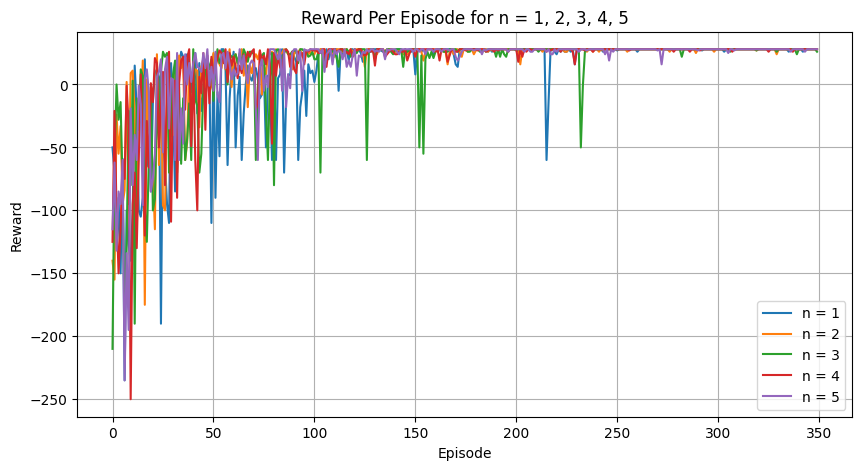

In [ ]:
plt.figure(figsize=(10,5))
for n in all_rewards:
    plt.plot(all_rewards[n], label=f"n = {n}")
plt.title("Reward Per Episode for n = 1, 2, 3, 4, 5")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.grid(True)
plt.show()


Plot the epsilon decay graph for each value of n.

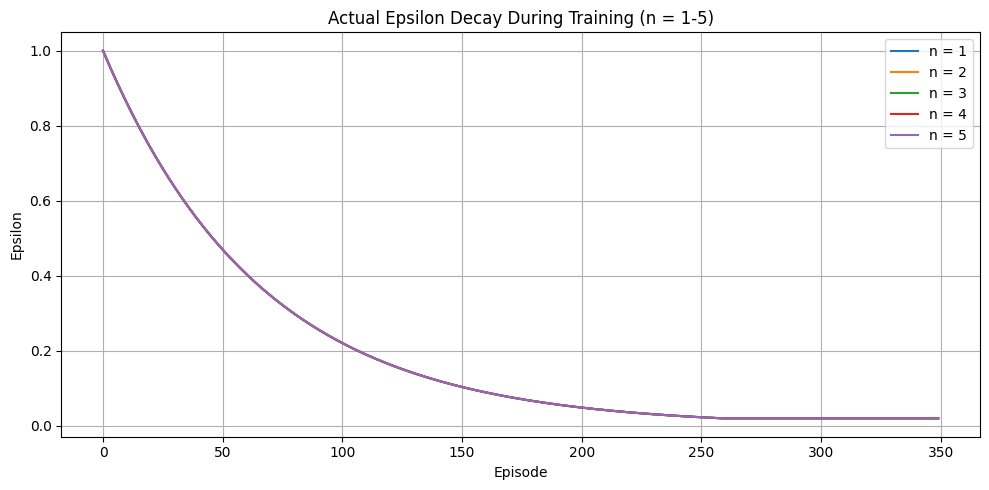

In [ ]:
plt.figure(figsize=(10,5))
for n in all_eps:
    plt.plot(all_eps[n], label=f"n = {n}")
plt.title("Actual Epsilon Decay During Training (n = 1-5)")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Run the environment for at least 10 episodes using only greedy actions for
each value of n. Plot the total reward per episode.

In [ ]:
def greedy_run(the_env, q_table_a, q_table_b, num_episodes=10, max_steps=50):
    score_list = []
    for ep in range(num_episodes):
        state_now, junk = the_env.reset()
        total_reward = 0

        for step_now in range(max_steps):
            act_now = np.argmax(q_table_a[state_now] + q_table_b[state_now])
            next_state, reward_now, terminal, junk1, junk2 = the_env.step(act_now)
            total_reward += reward_now
            state_now = next_state

            if terminal:
                break
        score_list.append(total_reward)
    return score_list

for n_val in [1, 2, 3, 4, 5]:
    greedy_scores = greedy_run(env, all_qA[n_val], all_qB[n_val])
    all_greedy[n_val] = greedy_scores

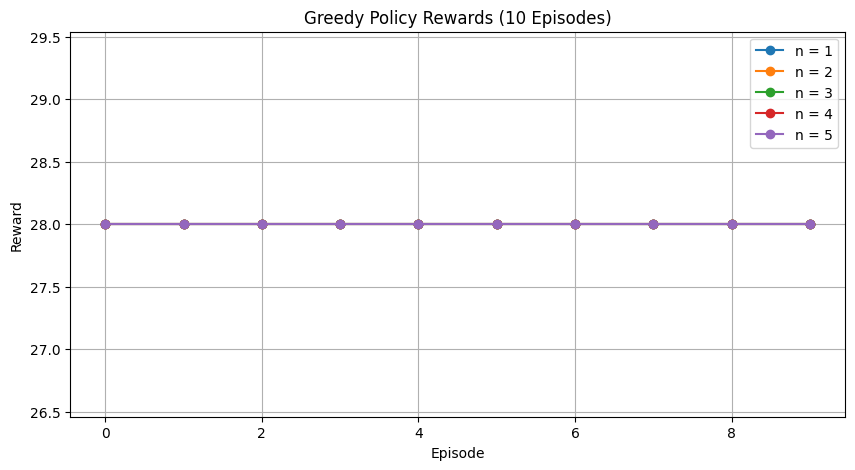

In [ ]:
plt.figure(figsize=(10,5))
for n in all_greedy:
    plt.plot(all_greedy[n], marker='o', label=f"n = {n}")
plt.title("Greedy Policy Rewards (10 Episodes)")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.grid(True)
plt.show()


Provide the evaluation results and your explanation. Suggest the most efficient n
value and hyperparameter setup for your problem.

### Evaluation (n = 1, 2, 3, 4, 5)

- **n = 1:** learns but unstable and noisy  
- **n = 2:** better, still fluctuates  
- **n = 3:** best overall — fast, stable, highest rewards  
- **n = 4:** slow learning  
- **n = 5:** inconsistent and delayed

**Greedy Test:**  
n = 3 consistently reached the goal with rewards = 28.

**Best n-step Value:**  
**n = 3**

**Best Hyperparameters Used:**
- episodes: 350  
- steps: 60  
- gamma: 0.90  
- learning rate: 0.25  
- epsilon decay: 0.985  
- epsilon min: 0.02  

**Summary:**  
n = 3 gave the smoothest learning curve and the best greedy performance, making it the most efficient setup.

5. Compare the performance of SARSA and n-step Double Q-learning algorithms on
the same environment (e.g. show one graph with two reward dynamics) and give
your interpretation of the results.

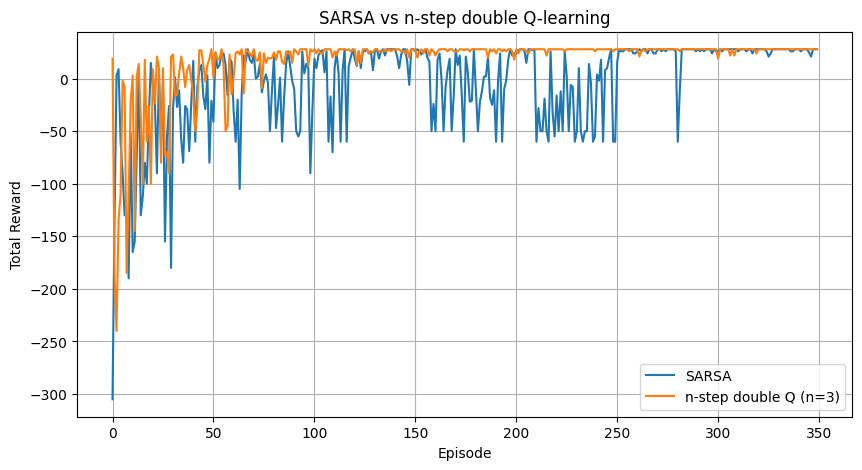

In [ ]:
q_sarsa, sarsa_rewards, eps_sarsa = runsarsa(env, episodes=350, stepmax=60, learnrate=0.2, discountrate=0.9, eps=1.0, epsdrop=0.99, epsmin=0.05)
qa, qb, dq_rewards, _ = run_double_q(env, 350, 60, 3, 0.25, 0.9, 1.0, 0.985, 0.02)

plt.figure(figsize=(10,5))
plt.plot(sarsa_rewards, label="SARSA")
plt.plot(dq_rewards, label="n-step double Q (n=3)")
plt.title("SARSA vs n-step double Q-learning")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.legend()
plt.grid(True)
plt.show()

The graph shows that SARSA (blue line) performs significantly better than n-step Double Q-learning. SARSA learns the task much quicker, reaching optimal rewards around episode 50 and staying stable afterwards. On the other hand, n-step Double Q-learning (orange line) takes much longer to learn, around 100-150 episodes, and keeps fluctuating even after it seems to have learned. The reason SARSA works better here is because it's an on-policy algorithm that updates based on actual actions taken, making it more stable. The n-step Double Q uses a 3-step lookahead which adds complexity and variance, causing those ups and downs throughout training. Overall, SARSA is more suitable for this environment.

References:
SARSA - https://www.geeksforgeeks.org/machine-learning/sarsa-reinforcement-learning/

gymnasium: https://gymnasium.farama.org/index.html

E-Greedy - https://www.baeldung.com/cs/epsilon-greedy-q-learning


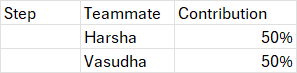